# Feature extractor and Patchifier test


In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO
from src.models.encoders import Encoder
from src.models.patchifier import Patchifier
# from src.data_loader.evaluation_data_generator import DataGenerator
from src.data_loader.data_module_lightning import SonarSimDataModule

In [41]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
train_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data'
batch_size = 2
num_workers = 0
transforms = None
dm = SonarSimDataModule(root_dir, batch_size, num_workers, transforms, train_config_pth)
dm.setup()
train_data_loader = dm.train_dataloader()

batch = next(iter(train_data_loader))
frames, time, trajectory, depth = batch

print('Input data format')
print(f'time: {time.shape}')
print(f'fls frame: {frames.shape}')
print(f'pose: {trajectory.shape}')
print(f'depth: {depth.shape}')



Input data format
time: torch.Size([2, 5, 1])
fls frame: torch.Size([2, 5, 1, 800, 768])
pose: torch.Size([2, 5, 7])
depth: torch.Size([2, 5, 1])


## 1. Encoder test

Encoder is responsible for extraction of features or context map from fls frame.


In [43]:
# instance of encoder 
model_encoder = Encoder(in_ch = 1, out_ch = 128, dim = 32, dropout=0.5, norm_fn ='instance') 

In [44]:
# pass through encoder

enc_output = model_encoder(frames)
print('Encoder')
print(f'input shape: {frames.shape}')
print(f'output shape: {enc_output.shape}')

Encoder
input shape: torch.Size([2, 5, 1, 800, 768])
output shape: torch.Size([2, 5, 128, 200, 192])


## 2. Patch extraction test

- Key Points detection
- Patch extraction (features and context from neighbour pixels of key points)
- Feature Map of whole fls frame 

In [45]:
from src.models.patchifier import Patchifier

In [ ]:
with open(model_config_pth, "r") as f:
    config = Box(yaml.safe_load(f))

patchifier = Patchifier(config)


In [51]:
# pass input sample image through patchifier module

coords, patches_f, patches_c, fmap = patchifier(frames, mode = 'harris')

print('Patchifier')
print(f'corrds shape: {coords.shape}') # coords of key points
print(f'patches features shape: {patches_f.shape}') 
print(f'patches contexts shape: {patches_c.shape}')
print(f'features map for whole frames shape: {fmap.shape}')



Patchifier
corrds shape: torch.Size([2, 5, 5, 2])
patches features shape: torch.Size([2, 5, 5, 128, 9])
patches contexts shape: torch.Size([2, 5, 5, 384])
features map for whole frames shape: torch.Size([2, 5, 128, 200, 192])


pt: 0: x=426, y=8
pt: 1: x=352, y=393
pt: 2: x=25, y=200
pt: 3: x=368, y=391
pt: 4: x=323, y=110
key points shape: (800, 768, 3)
harris_response shape: (800, 768)


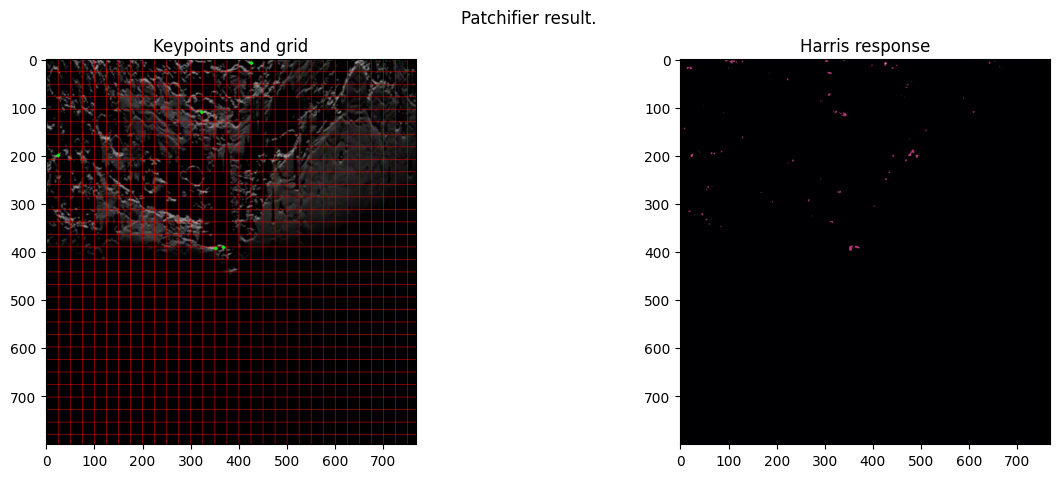

In [72]:
key_points_visu, harris_response = patchifier.get_visu(frames, coords, batch=1, frame_num=4)
print(f'key points shape: {key_points_visu.shape}')
print(f'harris_response shape: {harris_response.shape}')



fig, ax = plt.subplots(1, 2, figsize = (15,5))
fig.suptitle(f'Patchifier result.')

ax[0].set_title('Keypoints and grid')
ax[0].imshow(key_points_visu)


ax[1].set_title('Harris response')
ax[1].imshow(harris_response, cmap='magma')

plt.show()

